In [2]:
!pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 83.4 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.6
    Uninstalling numpy-2.4.6:
      Successfully uninstalled numpy-2.4.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires

# Comparative Experimental Analysis of Forecasting Methods
## Member 1 - Airline Passengers Dataset

**Course:** Applied Statistics and Experimental Analysis
**Dataset:** Airline Passengers monthly dataset
**Target variable:** Passengers
**Feature:** Passengers

This notebook follows the same experimental format as the provided notebook, but uses the Airline Passengers dataset.

1. Descriptive Statistical Analysis
2. Time Series Analysis (Trend, Seasonality, Stationarity - ADF, ACF/PACF)
3. Data Preprocessing (Missing values, Scaling, Sliding Window w=30, 80/20 split, seed=42)
4. Train 5 forecasting models: Holt-Winters, ARIMA/SARIMA, XGBoost, LSTM, Transformer
5. Evaluation (MAE, RMSE, MAPE, R²)
6. Statistical Comparison (Paired t-test / Wilcoxon)
7. Visualization & Discussion

---
### A note on fair comparison across model families

- The full series is split chronologically at `split_idx = floor(0.8 * N)` -> **no shuffling**, **seed=42** wherever randomness applies.
- A **sliding window of `w = 30`** is used to build supervised samples for XGBoost / LSTM / Transformer.
- Holt-Winters and ARIMA/SARIMA are fit on the **training portion only**, then forecast the test timestamps.
- **All 5 models are evaluated on the exact same set of target timestamps**, allowing paired t-test / Wilcoxon tests.
- Scaling is **fit on the training set only** and applied to the full series after fitting.

## 1. Setup & Imports

In [3]:
# If running for the first time, uncomment to install dependencies
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn statsmodels xgboost tensorflow

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

WINDOW = 30
TEST_RATIO = 0.20
DATA_URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
TARGET = "Passengers"

print("Setup complete. TensorFlow:", tf.__version__)

Setup complete. TensorFlow: 2.19.0


In [4]:
# Google Drive is not required for the public Airline Passengers CSV.
# If you later use a local file on Colab, mount Drive here.
# from google.colab import drive
# drive.mount('/content/drive')

## 2. Load Dataset

Loading the Airline Passengers dataset from a public CSV URL. The original columns are `Month` and `Passengers`.

In [5]:
df_raw = pd.read_csv(DATA_URL)
print(df_raw.shape)
df_raw.head()

(144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
# Standardize column names and parse monthly dates.
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

date_col_candidates = [c for c in df.columns if c.lower() in ["month", "date", "datetime", "timestamp"]]
date_col = date_col_candidates[0] if date_col_candidates else df.columns[0]
df[date_col] = pd.to_datetime(df[date_col])
df = df.rename(columns={date_col: "Date"})

target_candidates = [c for c in df.columns if c.lower() in ["passengers", "passenger"]]
target_col = target_candidates[0] if target_candidates else TARGET
df = df.rename(columns={target_col: TARGET})

df = df.sort_values("Date").reset_index(drop=True)
df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")
df = df.set_index("Date")
df = df[[TARGET]]
df[TARGET] = df[TARGET].interpolate().ffill().bfill()

print(df.shape)
df.head()

(144, 1)


,Passengers
Date,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [7]:
# Airline is a univariate dataset.
FEATURES = [TARGET]
df = df[FEATURES]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


## 3. Descriptive Statistical Analysis (Step 1)

Required statistics: N, Mean, Median, Variance, Std, Min, Max, Skewness, Kurtosis.

In [8]:
desc_stats = pd.DataFrame({
    "N": df.count(),
    "Mean": df.mean(),
    "Median": df.median(),
    "Variance": df.var(),
    "Std": df.std(),
    "Min": df.min(),
    "Max": df.max(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurtosis()
})
desc_stats

,N,Mean,Median,Variance,Std,Min,Max,Skewness,Kurtosis
Passengers,144,280.298611,265.5,14391.917201,119.966317,104,622,0.58316,-0.364942


In [9]:
print(f"Missing values per column:\n{df.isna().sum()}")
print(f"\nDate range: {df.index.min()} -> {df.index.max()}")
print(f"Total observations: {len(df)}")

Missing values per column:
Passengers    0
dtype: int64

Date range: 1949-01-01 00:00:00 -> 1960-12-01 00:00:00
Total observations: 144


### 3.1 Histogram — Distribution Analysis

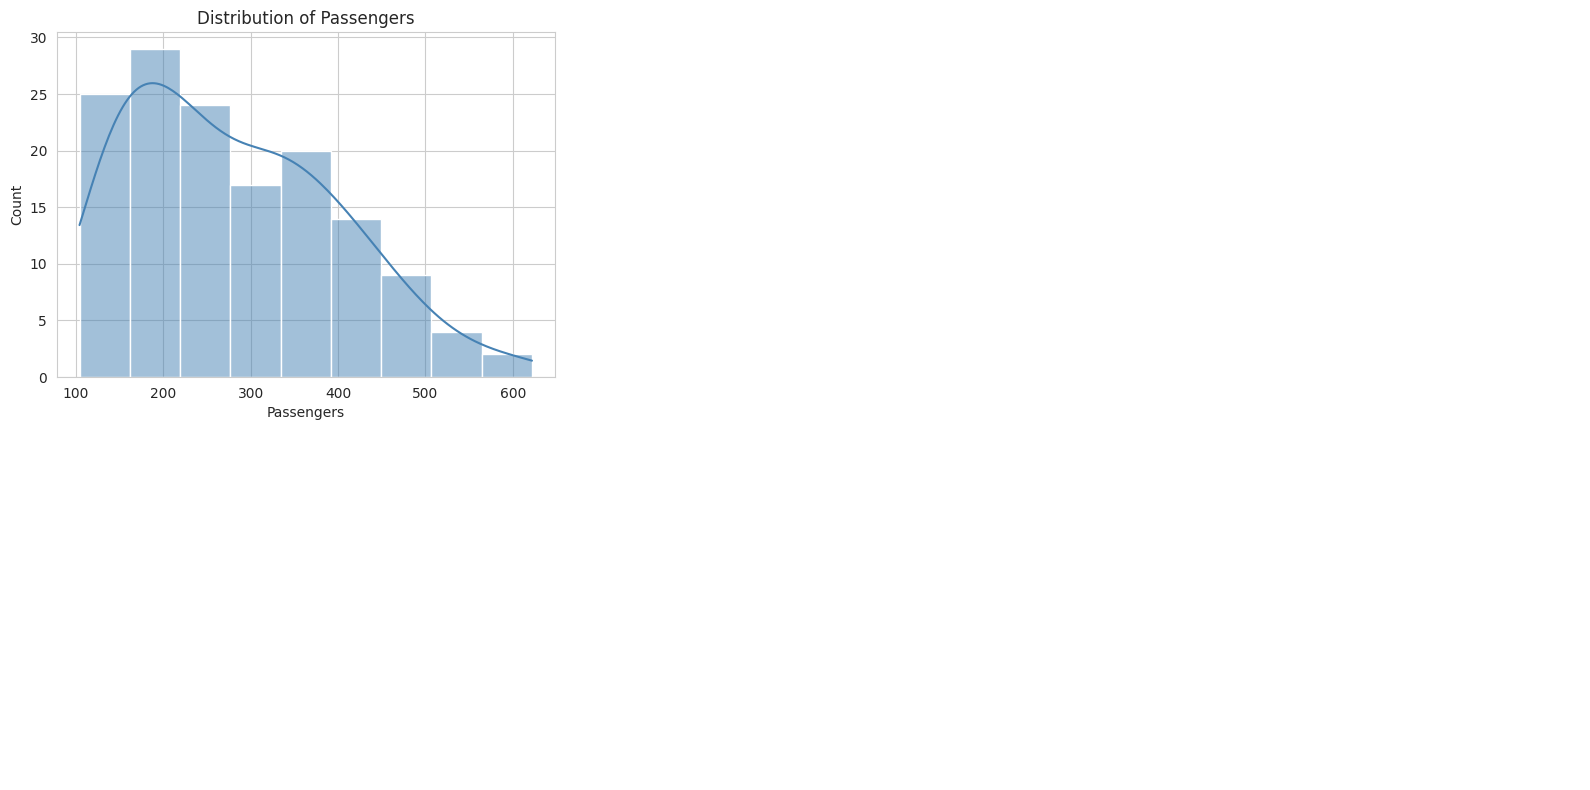

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
for ax in axes.flatten()[len(FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 3.2 Boxplot — Outlier Detection

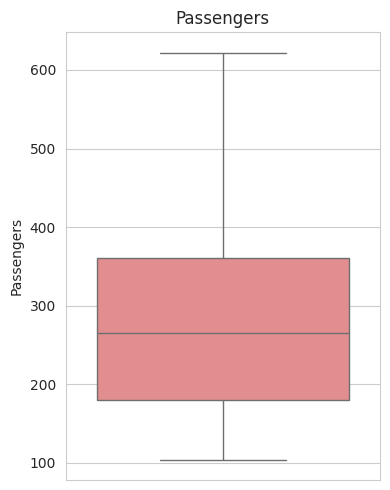

In [11]:
fig, axes = plt.subplots(1, len(FEATURES), figsize=(4*len(FEATURES), 5))
if len(FEATURES) == 1:
    axes = [axes]
for ax, col in zip(axes, FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="lightcoral")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.3 Time Series Plot — Trend & Seasonality (Passengers)

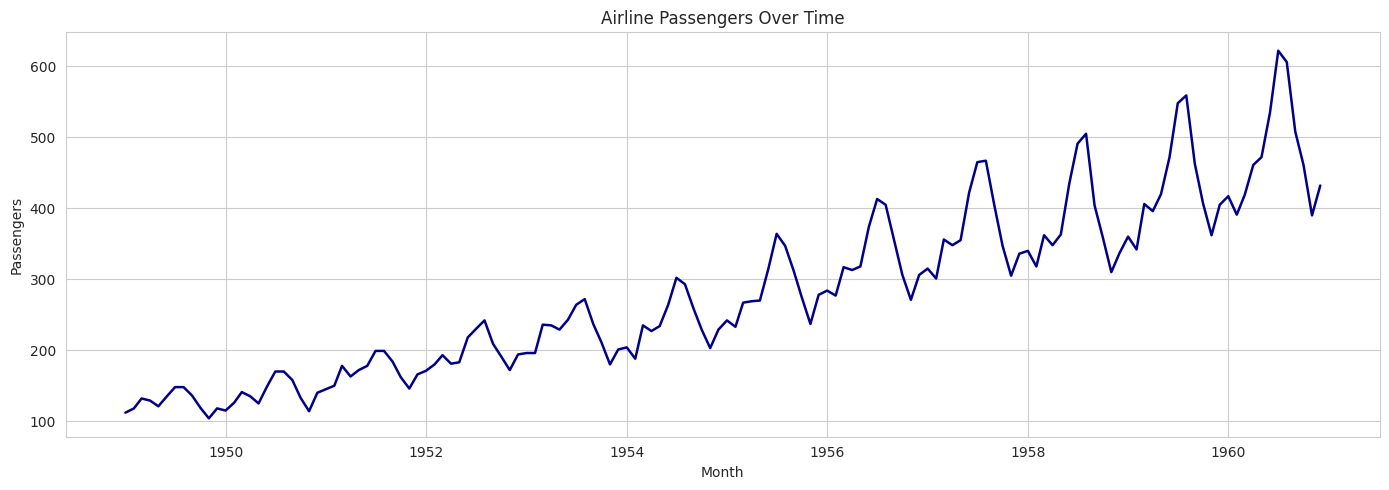

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df[TARGET], color="darkblue", linewidth=1.8)
plt.title("Airline Passengers Over Time")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.tight_layout()
plt.show()

## 4. Time Series Analysis (Step 2)

### 4.1 Trend & Seasonal Decomposition

Airline Passengers is monthly data with a clear yearly seasonal cycle, so we use `period = 12`.

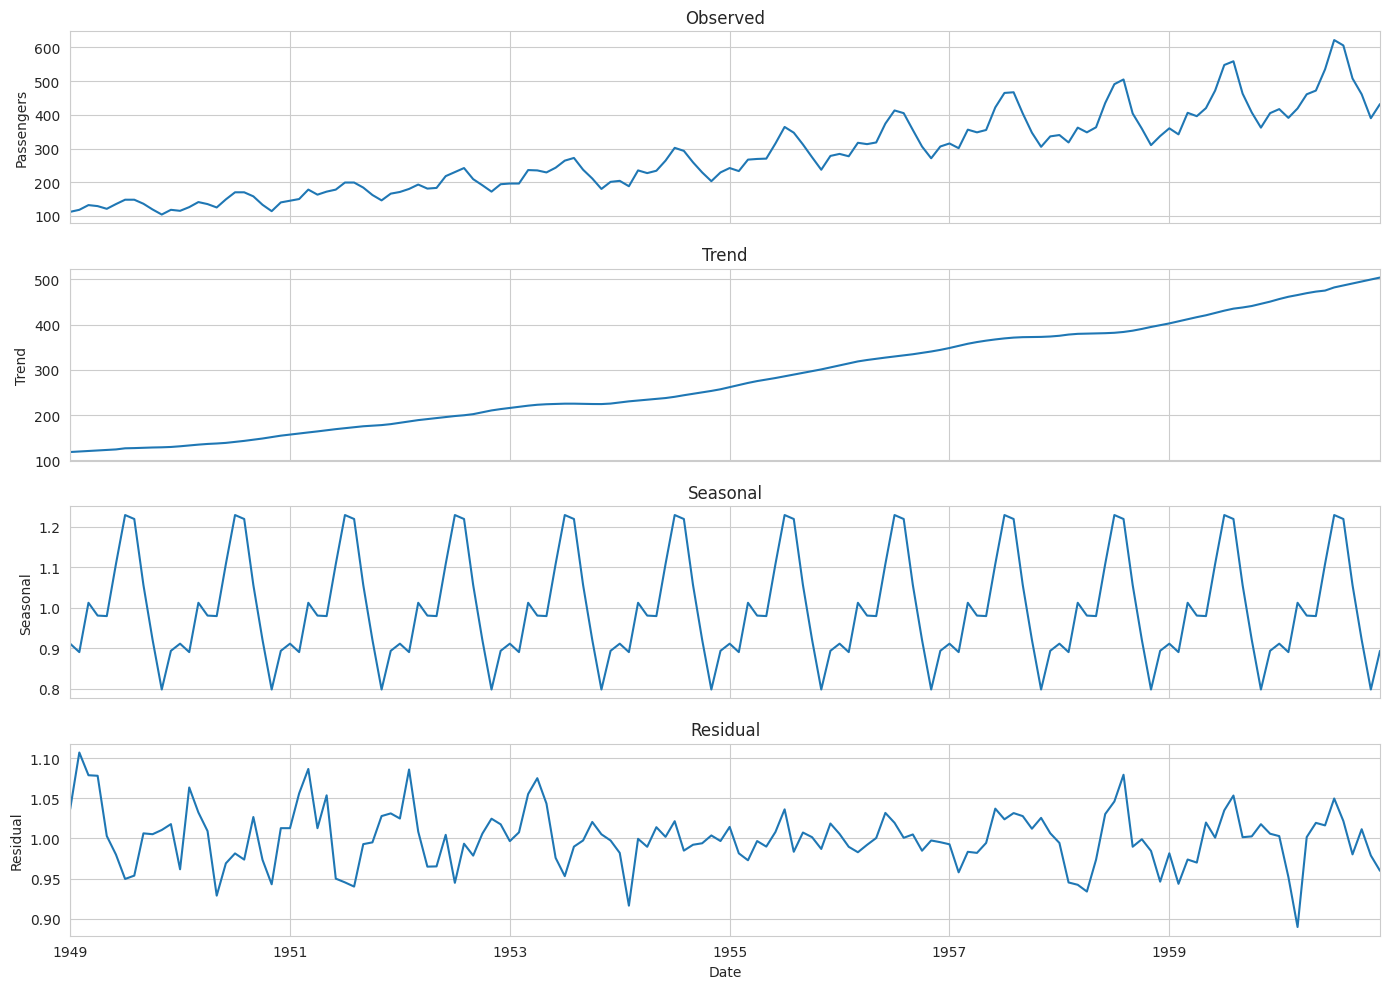

In [13]:
period = 12
decomposition = seasonal_decompose(df[TARGET], model="multiplicative", period=period, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Observed"); axes[0].set_ylabel("Passengers")
decomposition.trend.plot(ax=axes[1], title="Trend"); axes[1].set_ylabel("Trend")
decomposition.seasonal.plot(ax=axes[2], title="Seasonal"); axes[2].set_ylabel("Seasonal")
decomposition.resid.plot(ax=axes[3], title="Residual"); axes[3].set_ylabel("Residual")
plt.tight_layout()
plt.show()

### 4.2 Stationarity Analysis — Augmented Dickey-Fuller (ADF) Test

**H₀:** The series is non-stationary (has a unit root)
**H₁:** The series is stationary

Airline passenger counts have strong trend and seasonality, so the raw level series is expected to be **non-stationary**. We also test the first difference and log difference for reference.

In [14]:
def adf_report(series, name):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    for k, v in result[4].items():
        print(f"Critical Value ({k}) : {v:.4f}")
    conclusion = "Stationary (reject H0)" if result[1] < 0.05 else "Non-stationary (fail to reject H0)"
    print(f"Conclusion    : {conclusion}\n")
    return result[1]

p_raw = adf_report(df[TARGET], "Passengers (raw level)")
p_diff = adf_report(df[TARGET].diff(), "Passengers (1st difference)")
p_logdiff = adf_report(np.log(df[TARGET]).diff(), "Passengers (log difference)")

--- ADF Test: Passengers (raw level) ---
ADF Statistic : 0.8154
p-value       : 0.9919
Critical Value (1%) : -3.4817
Critical Value (5%) : -2.8840
Critical Value (10%) : -2.5788
Conclusion    : Non-stationary (fail to reject H0)

--- ADF Test: Passengers (1st difference) ---
ADF Statistic : -2.8293
p-value       : 0.0542
Critical Value (1%) : -3.4817
Critical Value (5%) : -2.8840
Critical Value (10%) : -2.5788
Conclusion    : Non-stationary (fail to reject H0)

--- ADF Test: Passengers (log difference) ---
ADF Statistic : -2.7171
p-value       : 0.0711
Critical Value (1%) : -3.4825
Critical Value (5%) : -2.8844
Critical Value (10%) : -2.5790
Conclusion    : Non-stationary (fail to reject H0)



### 4.3 Autocorrelation Analysis — ACF / PACF

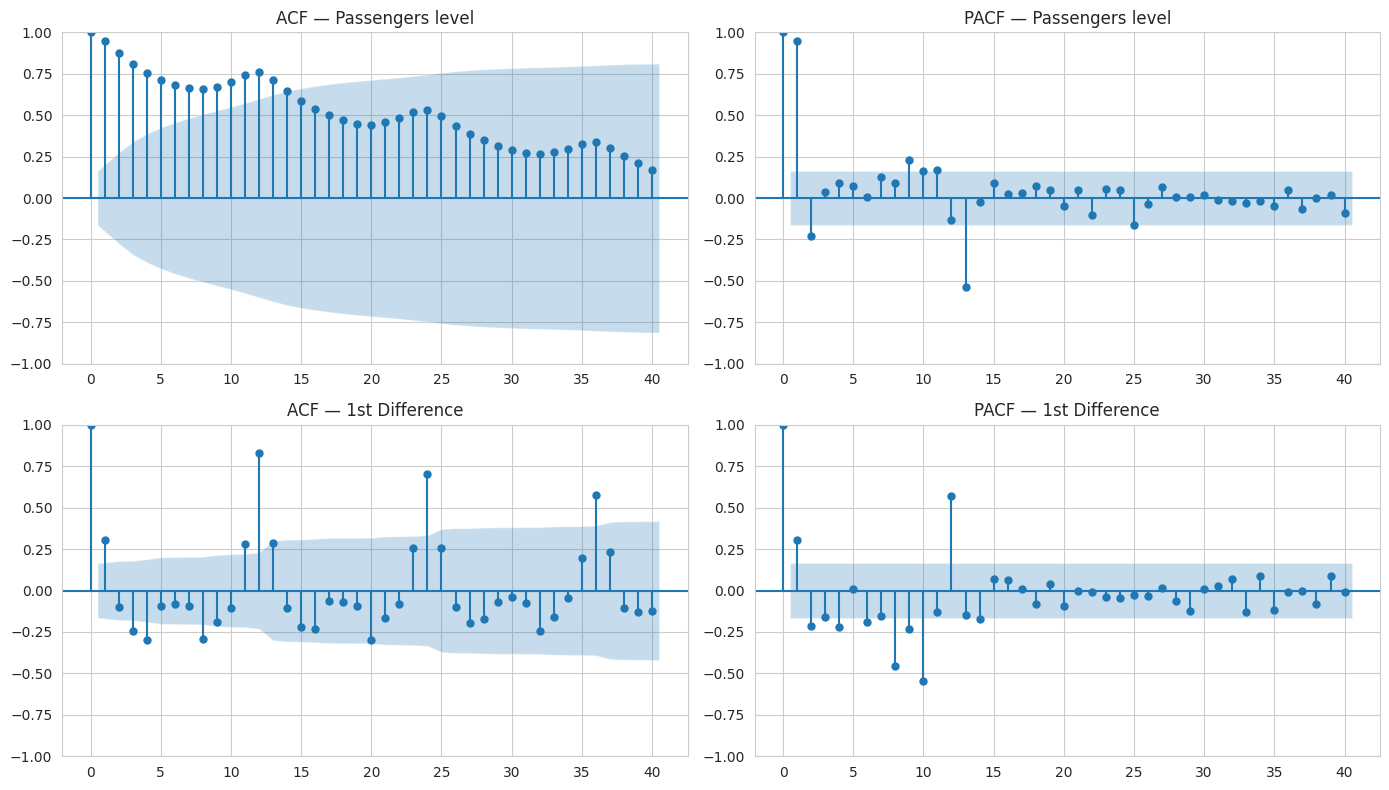

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(df[TARGET], lags=40, ax=axes[0,0]); axes[0,0].set_title("ACF — Passengers level")
plot_pacf(df[TARGET], lags=40, ax=axes[0,1], method="ywm"); axes[0,1].set_title("PACF — Passengers level")
plot_acf(df[TARGET].diff().dropna(), lags=40, ax=axes[1,0]); axes[1,0].set_title("ACF — 1st Difference")
plot_pacf(df[TARGET].diff().dropna(), lags=40, ax=axes[1,1], method="ywm"); axes[1,1].set_title("PACF — 1st Difference")
plt.tight_layout()
plt.show()

## 5. Data Preprocessing (Step 3)

Pipeline (identical procedure required by the project spec):
1. **Missing values** → Forward Fill, then Interpolation for any remainder
2. **Train/Test split** → 80% / 20%, chronological, **no shuffling**
3. **Scaling** → MinMaxScaler, **fit on train only**
4. **Sliding window** → `w = 30`, used to build supervised samples for XGBoost/LSTM/Transformer
5. **Seed** → 42 everywhere randomness is involved

In [16]:
# 5.1 Missing values
df_clean = df.copy()
df_clean = df_clean.ffill()
df_clean = df_clean.interpolate(method="linear")
print("Remaining NaNs:", df_clean.isna().sum().sum())

Remaining NaNs: 0


In [17]:
# 5.2 Chronological 80/20 split (index-based, shared by ALL models)
N = len(df_clean)
split_idx = int(N * (1 - TEST_RATIO))
print(f"Total obs: {N} | Train: {split_idx} | Test: {N - split_idx}")

train_df = df_clean.iloc[:split_idx]
test_df  = df_clean.iloc[split_idx:]
print("Train range:", train_df.index.min(), "->", train_df.index.max())
print("Test range :", test_df.index.min(), "->", test_df.index.max())

Total obs: 144 | Train: 115 | Test: 29
Train range: 1949-01-01 00:00:00 -> 1958-07-01 00:00:00
Test range : 1958-08-01 00:00:00 -> 1960-12-01 00:00:00


In [18]:
# 5.3 Scaling (fit on TRAIN ONLY to avoid leakage) - for ML/DL inputs
scaler = MinMaxScaler()
scaler.fit(train_df[FEATURES])

scaled_all = pd.DataFrame(
    scaler.transform(df_clean[FEATURES]),
    columns=FEATURES, index=df_clean.index
)
target_idx_in_features = FEATURES.index(TARGET)

In [19]:
# 5.4 Sliding window dataset builder (w = 30) for ML/DL models
def build_windows(scaled_df, window=WINDOW, target_col=TARGET, feature_cols=FEATURES):
    values = scaled_df[feature_cols].values
    target_pos = feature_cols.index(target_col)
    X, y, idx = [], [], []
    for t in range(window, len(values)):
        X.append(values[t-window:t, :])          # shape (window, n_features)
        y.append(values[t, target_pos])           # scaled target at time t
        idx.append(scaled_df.index[t])
    return np.array(X), np.array(y), pd.DatetimeIndex(idx)

X_all, y_all, idx_all = build_windows(scaled_all)
print("X_all shape:", X_all.shape, "| y_all shape:", y_all.shape)

# Align with the SAME chronological split_idx used above.
# Sample at original time index t belongs to test set if t >= split_idx.
window_split_idx = split_idx - WINDOW   # offset because first WINDOW points have no sample

X_train, y_train = X_all[:window_split_idx], y_all[:window_split_idx]
X_test,  y_test_scaled  = X_all[window_split_idx:], y_all[window_split_idx:]
idx_test = idx_all[window_split_idx:]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Test target timestamps:", idx_test.min(), "->", idx_test.max())
assert len(idx_test) == (N - split_idx), "Test alignment mismatch!"

X_all shape: (114, 30, 1) | y_all shape: (114,)
X_train: (85, 30, 1) X_test: (29, 30, 1)
Test target timestamps: 1958-08-01 00:00:00 -> 1960-12-01 00:00:00


In [20]:
# True (unscaled) test targets — the ground truth used for ALL models' evaluation
y_test_true = df_clean.loc[idx_test, TARGET].values
print(y_test_true[:5], "...", len(y_test_true), "points")

[505 404 359 310 337] ... 29 points


In [21]:
# Helper to inverse-transform a scaled Passengers prediction back to original units.
def inverse_target(scaled_target_values):
    scaled_target_values = np.asarray(scaled_target_values).reshape(-1)
    dummy = np.zeros((len(scaled_target_values), len(FEATURES)))
    dummy[:, target_idx_in_features] = scaled_target_values
    return scaler.inverse_transform(dummy)[:, target_idx_in_features]

## 6. Evaluation Metric Helper (MAE, RMSE, MAPE, R²)

In [22]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    print(f"[{model_name}] MAE={mae:.4f} | RMSE={rmse:.4f} | MAPE={mape:.2f}% | R2={r2:.4f}")
    return {"Model": model_name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2}

results = []          # summary metrics, one row per model
errors_by_model = {}  # per-timestamp absolute errors, for paired statistical tests
preds_by_model = {}   # store predictions for plotting

## 7. Model 1 — Holt-Winters Exponential Smoothing (Step 4)

Airline Passengers has strong trend and yearly seasonality, so Holt-Winters uses additive trend and multiplicative seasonality with period = 12.

In [23]:
import time
t0 = time.time()

hw_model = ExponentialSmoothing(
    train_df[TARGET],
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated"
)
hw_fit = hw_model.fit(optimized=True)
hw_preds = hw_fit.forecast(len(idx_test)).values

hw_time = time.time() - t0
print(f"Holt-Winters training + forecast time: {hw_time:.2f}s")

Holt-Winters training + forecast time: 0.18s


In [24]:
res = evaluate(y_test_true, hw_preds, "Holt-Winters")
res["TrainTime_s"] = hw_time
results.append(res)
errors_by_model["Holt-Winters"] = np.abs(y_test_true - hw_preds)
preds_by_model["Holt-Winters"] = hw_preds

[Holt-Winters] MAE=21.9620 | RMSE=26.0419 | MAPE=4.82% | R2=0.8889


## 8. Model 2 — ARIMA / SARIMA (Step 5)

Order `(p,d,q)` is chosen via a small grid search on AIC over the training set. Because Airline Passengers has clear monthly seasonality, the final model uses `seasonal_order=(1,1,1,12)`.

In [25]:
from itertools import product

def select_arima_order(train_series, p_range=range(0,3), d=1, q_range=range(0,3)):
    best_aic, best_order = np.inf, (1,1,1)
    for p, q in product(p_range, q_range):
        try:
            m = ARIMA(train_series, order=(p, d, q)).fit()
            if m.aic < best_aic:
                best_aic, best_order = m.aic, (p, d, q)
        except Exception:
            continue
    return best_order, best_aic

best_order, best_aic = select_arima_order(train_df[TARGET])
print("Selected ARIMA order:", best_order, "AIC:", round(best_aic, 2))

Selected ARIMA order: (1, 1, 2) AIC: 1057.33


In [26]:
t0 = time.time()

sarima_model = SARIMAX(
    train_df[TARGET],
    order=best_order,
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
arima_preds = sarima_fit.forecast(steps=len(idx_test)).values

arima_time = time.time() - t0
print(f"ARIMA/SARIMA training + forecast time: {arima_time:.2f}s")

ARIMA/SARIMA training + forecast time: 0.73s


In [27]:
res = evaluate(y_test_true, arima_preds, "ARIMA/SARIMA")
res["TrainTime_s"] = arima_time
results.append(res)
errors_by_model["ARIMA/SARIMA"] = np.abs(y_test_true - arima_preds)
preds_by_model["ARIMA/SARIMA"] = arima_preds

[ARIMA/SARIMA] MAE=26.0638 | RMSE=32.5745 | MAPE=5.60% | R2=0.8262


## 9. Model 3 — XGBoost (Step 6)

Uses the windowed univariate dataset (`X_train`, `X_test`, window=30). Each sample is a 30-month history of passenger counts.

In [28]:
print(results)

[{'Model': 'Holt-Winters', 'MAE': 21.962008308170425, 'RMSE': np.float64(26.041879997711003), 'MAPE': np.float64(4.818737792374271), 'R2': 0.888904801923816, 'TrainTime_s': 0.18283534049987793}, {'Model': 'ARIMA/SARIMA', 'MAE': 26.063772120583838, 'RMSE': np.float64(32.574528694900394), 'MAPE': np.float64(5.598832764461375), 'R2': 0.8261771354696915, 'TrainTime_s': 0.7331557273864746}]


In [29]:
# Flatten window for XGBoost: (n_samples, window*n_features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=500, max_depth=3, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    objective="reg:squarederror", random_state=SEED
)
xgb_model.fit(X_train_flat, y_train)
xgb_train_time = time.time() - t0

t0 = time.time()
xgb_pred_scaled = xgb_model.predict(X_test_flat)
xgb_infer_time = time.time() - t0

xgb_preds = inverse_target(xgb_pred_scaled)
print(f"XGBoost train time: {xgb_train_time:.2f}s | inference time: {xgb_infer_time:.4f}s")

XGBoost train time: 0.24s | inference time: 0.0041s


In [30]:
res = evaluate(y_test_true, xgb_preds, "XGBoost")
res["TrainTime_s"] = xgb_train_time
results.append(res)
errors_by_model["XGBoost"] = np.abs(y_test_true - xgb_preds)
preds_by_model["XGBoost"] = xgb_preds

[XGBoost] MAE=45.4868 | RMSE=60.1984 | MAPE=9.52% | R2=0.4064


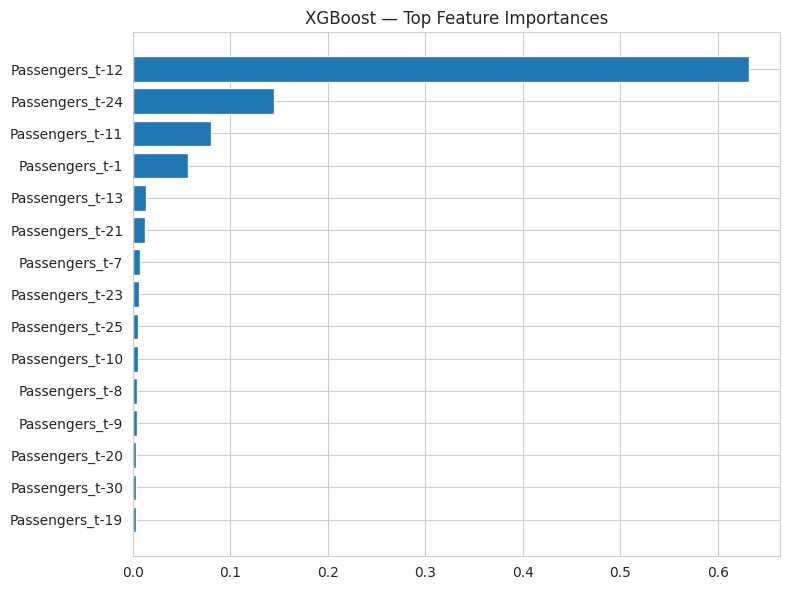

In [31]:
# Feature importance across the flattened window
importances = xgb_model.feature_importances_
top_n = min(15, len(importances))
top_idx = np.argsort(importances)[-top_n:]
feat_labels = [f"{TARGET}_t-{WINDOW - i}" for i in range(WINDOW)]

plt.figure(figsize=(8,6))
plt.barh(range(top_n), importances[top_idx])
plt.yticks(range(top_n), [feat_labels[i] for i in top_idx])
plt.title("XGBoost — Top Feature Importances")
plt.tight_layout()
plt.show()

## 10. Model 4 — LSTM (Step 7)

Sequential deep learning model using the same windowed input `X_train` (3D: samples, window, features).

In [32]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_features = X_train.shape[2]

lstm_model = models.Sequential([
    layers.Input(shape=(WINDOW, n_features)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])
lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

2026-06-25 04:21:32.507377: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0
)
lstm_train_time = time.time() - t0
print(f"LSTM train time: {lstm_train_time:.2f}s | epochs run: {len(history_lstm.history['loss'])}")

LSTM train time: 8.51s | epochs run: 31


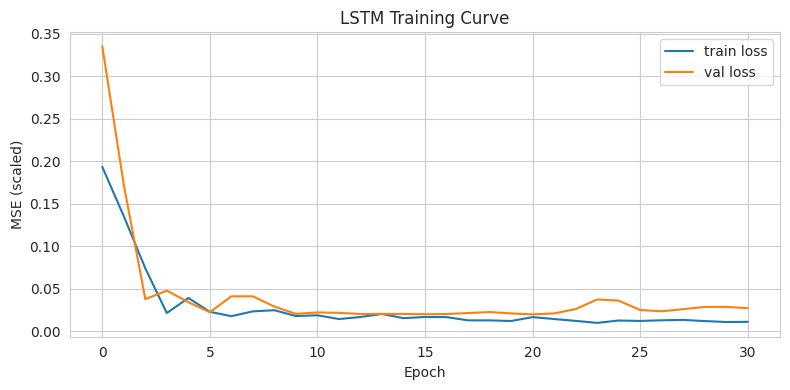

In [34]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history["loss"], label="train loss")
plt.plot(history_lstm.history["val_loss"], label="val loss")
plt.title("LSTM Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

In [35]:
t0 = time.time()
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
lstm_infer_time = time.time() - t0

lstm_preds = inverse_target(lstm_pred_scaled)
res = evaluate(y_test_true, lstm_preds, "LSTM")
res["TrainTime_s"] = lstm_train_time
results.append(res)
errors_by_model["LSTM"] = np.abs(y_test_true - lstm_preds)
preds_by_model["LSTM"] = lstm_preds
print(f"Inference time: {lstm_infer_time:.4f}s")

[LSTM] MAE=59.2767 | RMSE=79.8920 | MAPE=12.55% | R2=-0.0456
Inference time: 0.3514s


## 11. Model 5 — Transformer (Step 8)

Lightweight Transformer encoder (multi-head self-attention + feed-forward block) for
sequence regression, using the same windowed input as LSTM/XGBoost.

In [36]:
def transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.2):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    res = x
    x = layers.Dense(ff_dim, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(inputs.shape[-1])(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + res)
    return x

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

inputs = layers.Input(shape=(WINDOW, n_features))
x = transformer_encoder(inputs)
x = transformer_encoder(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1)(x)

transformer_model = models.Model(inputs, outputs)
transformer_model.compile(optimizer="adam", loss="mse")
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │      1,793 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 1)     │          0 │ dropout_1[0][0],  │
│                     │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 1)     │        129 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 1)     │          0 │ dense_1[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 1)     │      1,793 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 30, 1)     │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 1)     │          0 │ dropout_4[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 128)   │        256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 30, 128)   │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 30, 1)     │        129 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 1)     │          0 │ dense_3[0][0],    │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 1)     │          2 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 4,461 (17.43 KB)

 Trainable params: 4,461 (17.43 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop_tr = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

t0 = time.time()
history_tr = transformer_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100, batch_size=32,
    callbacks=[early_stop_tr], verbose=0
)
tr_train_time = time.time() - t0
print(f"Transformer train time: {tr_train_time:.2f}s | epochs run: {len(history_tr.history['loss'])}")

Transformer train time: 22.52s | epochs run: 100


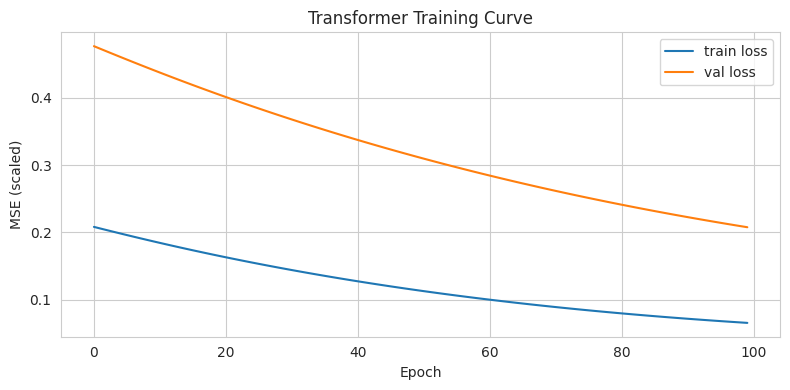

In [38]:
plt.figure(figsize=(8,4))
plt.plot(history_tr.history["loss"], label="train loss")
plt.plot(history_tr.history["val_loss"], label="val loss")
plt.title("Transformer Training Curve"); plt.xlabel("Epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.tight_layout(); plt.show()

In [39]:
t0 = time.time()
tr_pred_scaled = transformer_model.predict(X_test, verbose=0).flatten()
tr_infer_time = time.time() - t0

tr_preds = inverse_target(tr_pred_scaled)
res = evaluate(y_test_true, tr_preds, "Transformer")
res["TrainTime_s"] = tr_train_time
results.append(res)
errors_by_model["Transformer"] = np.abs(y_test_true - tr_preds)
preds_by_model["Transformer"] = tr_preds
print(f"Inference time: {tr_infer_time:.4f}s")

[Transformer] MAE=241.1301 | RMSE=253.4723 | MAPE=53.39% | R2=-9.5247
Inference time: 0.3456s


## 12. Performance Comparison Table (Step 9 & 10)

In [40]:
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df[["MAE", "RMSE", "MAPE", "R2", "TrainTime_s"]]
results_df.sort_values("RMSE")

,MAE,RMSE,MAPE,R2,TrainTime_s
Model,,,,,
Holt-Winters,21.962008,26.041880,4.818738,0.888905,0.182835
ARIMA/SARIMA,26.063772,32.574529,5.598833,0.826177,0.733156
XGBoost,45.486752,60.198424,9.522700,0.406363,0.241042
LSTM,59.276653,79.892040,12.552548,-0.045581,8.510623
Transformer,241.130089,253.472305,53.392047,-9.524747,22.522889


In [41]:
results_df.to_csv("airline_model_comparison_results.csv")
print("Saved: airline_model_comparison_results.csv")

Saved: airline_model_comparison_results.csv


## 13. Visualization of Results

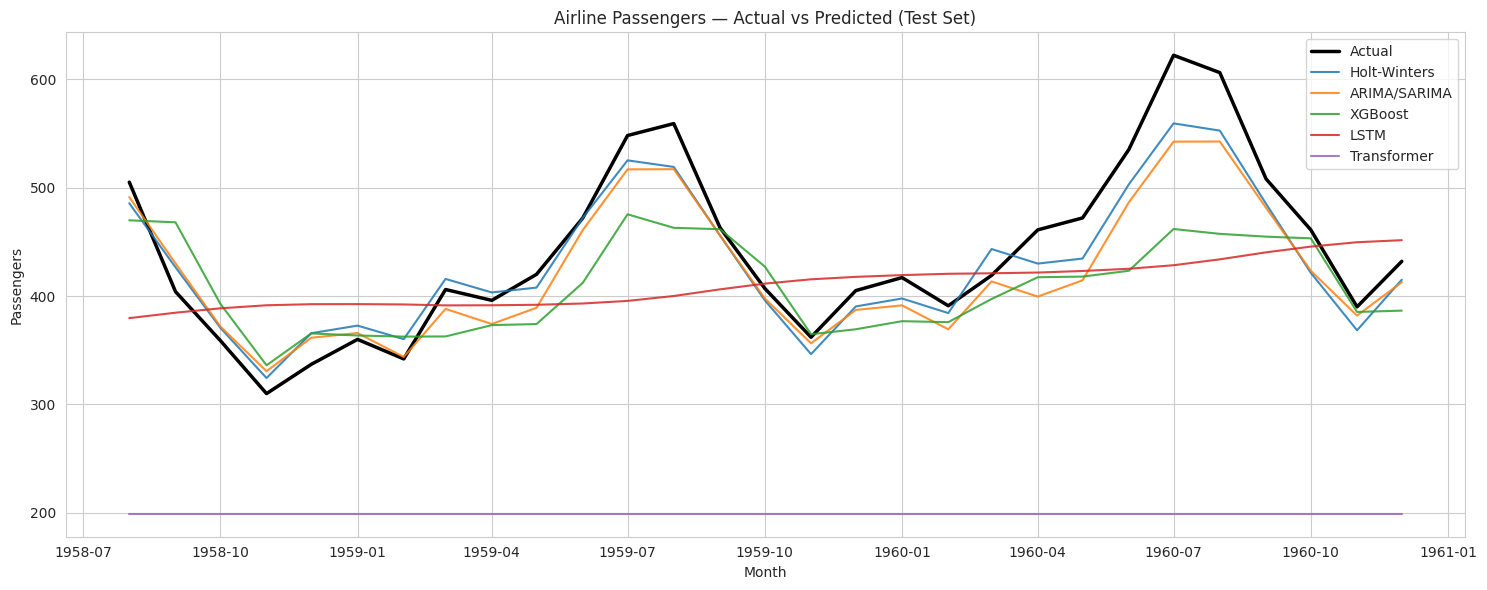

In [42]:
# 13.1 Predicted vs Actual — all models overlay
plt.figure(figsize=(15, 6))
plt.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=2.5)
for name, preds in preds_by_model.items():
    plt.plot(idx_test, preds, label=name, alpha=0.85, linewidth=1.5)
plt.title("Airline Passengers — Actual vs Predicted (Test Set)")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

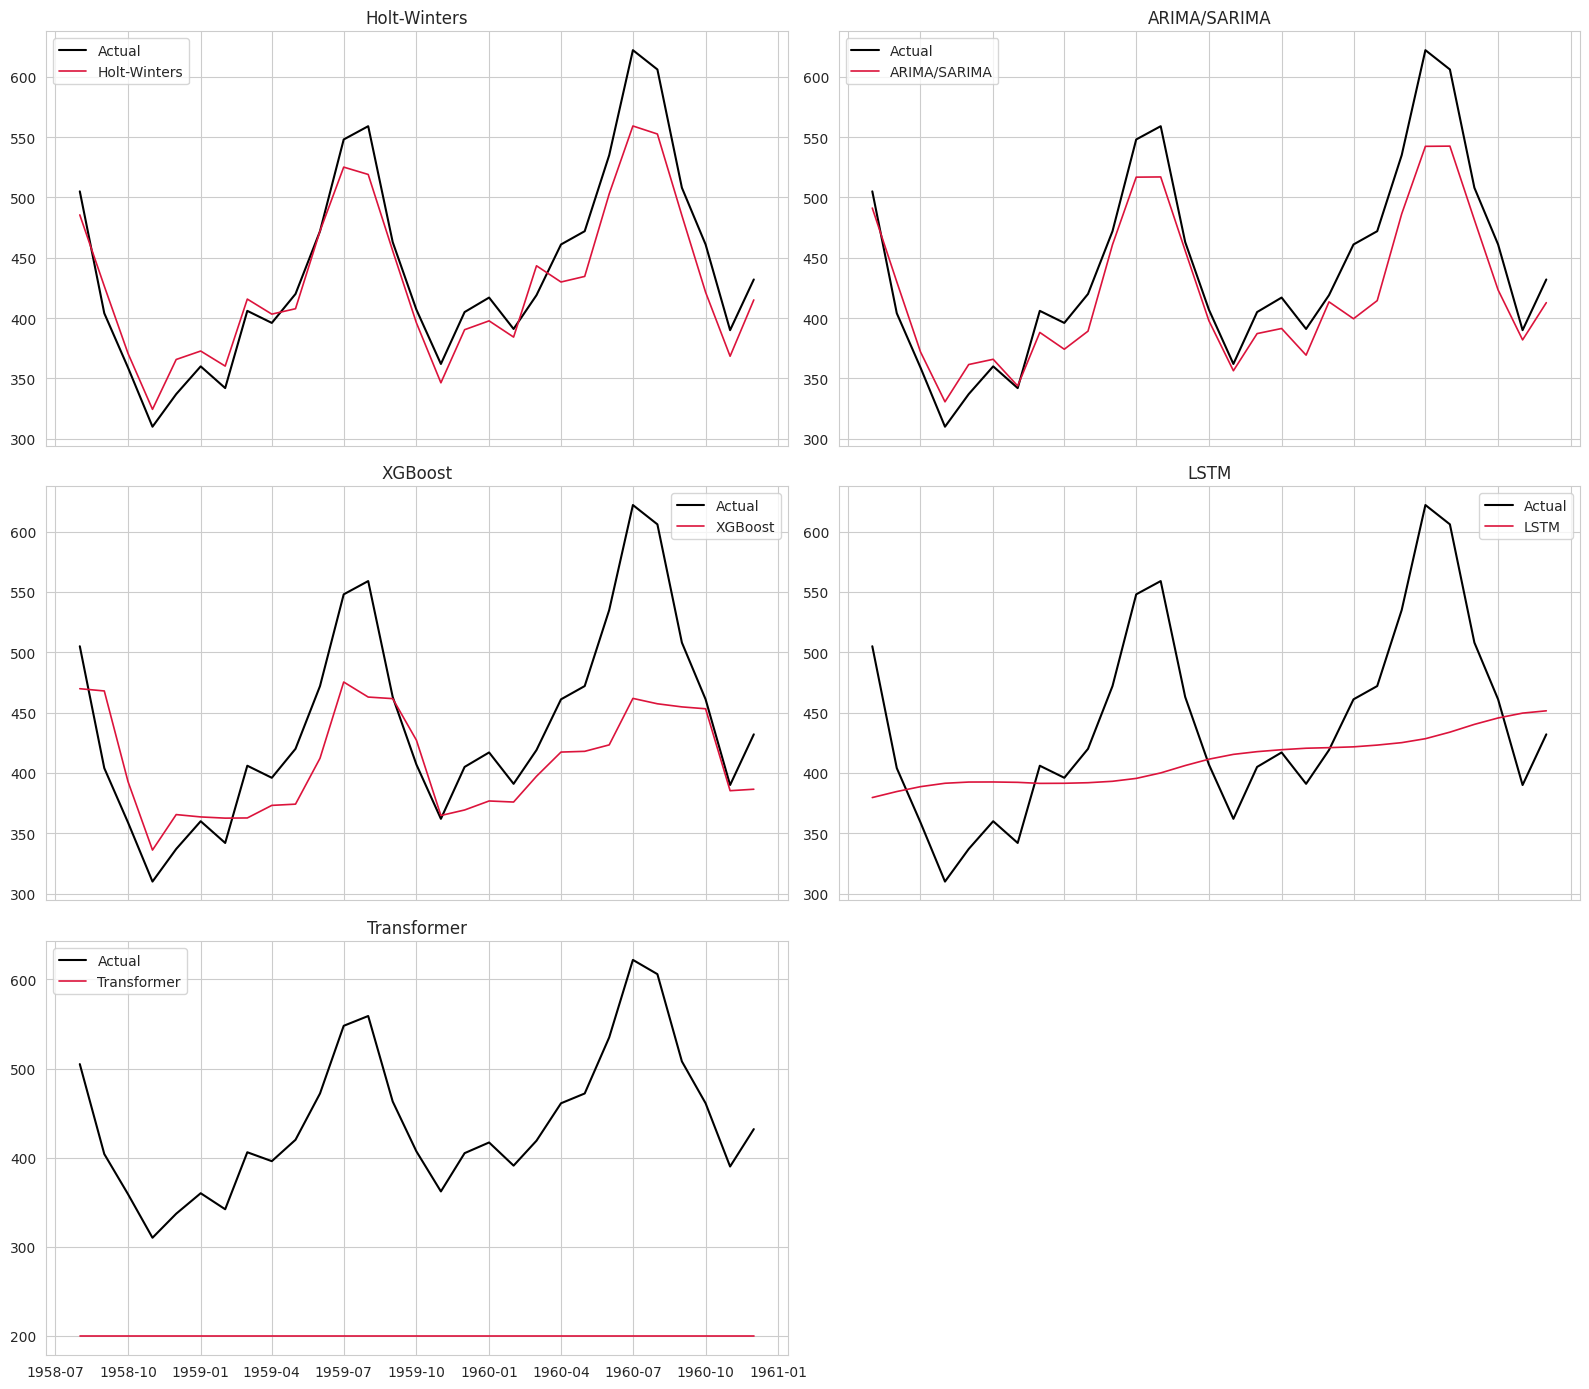

In [43]:
# 13.2 Individual subplots per model
fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=True)
for ax, (name, preds) in zip(axes.flatten(), preds_by_model.items()):
    ax.plot(idx_test, y_test_true, label="Actual", color="black", linewidth=1.5)
    ax.plot(idx_test, preds, label=name, color="crimson", linewidth=1.2)
    ax.set_title(name)
    ax.legend()
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

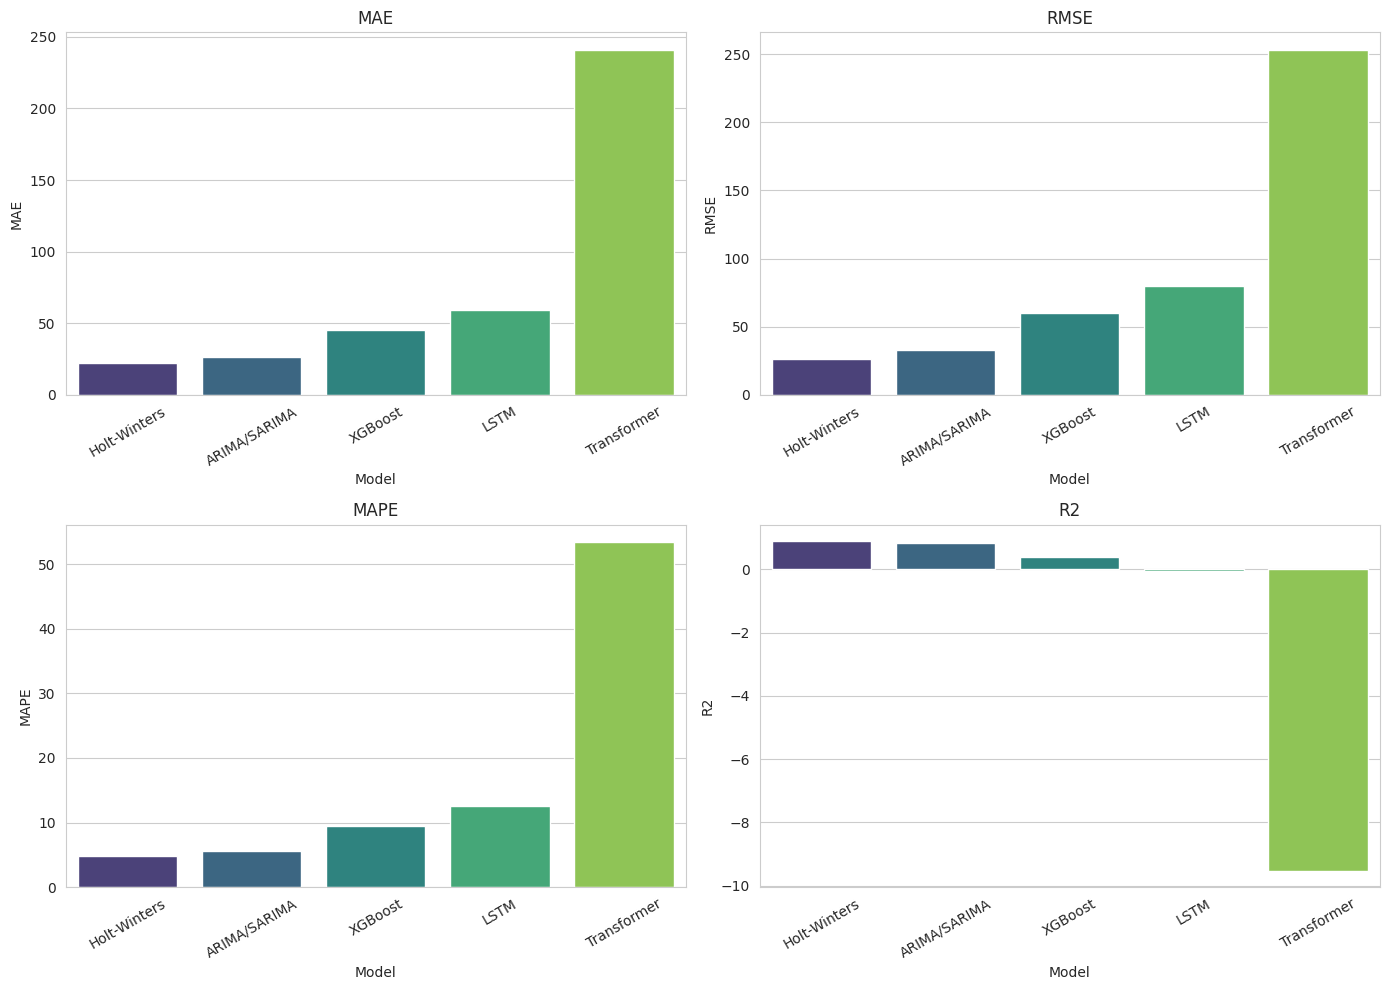

In [44]:
# 13.3 Metric comparison bar charts
metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), metrics_to_plot):
    sns.barplot(x=results_df.index, y=results_df[metric], ax=ax, palette="viridis")
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

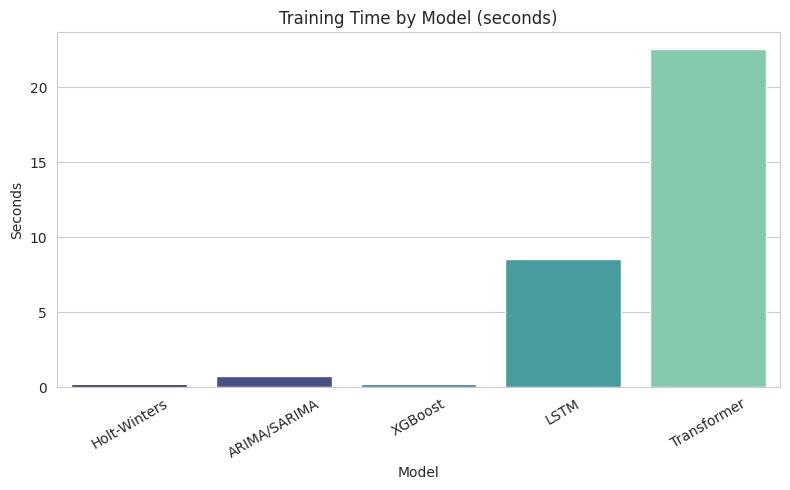

In [45]:
# 13.4 Training vs Inference time (computational cost)
plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y=results_df["TrainTime_s"], palette="mako")
plt.title("Training Time by Model (seconds)")
plt.ylabel("Seconds"); plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

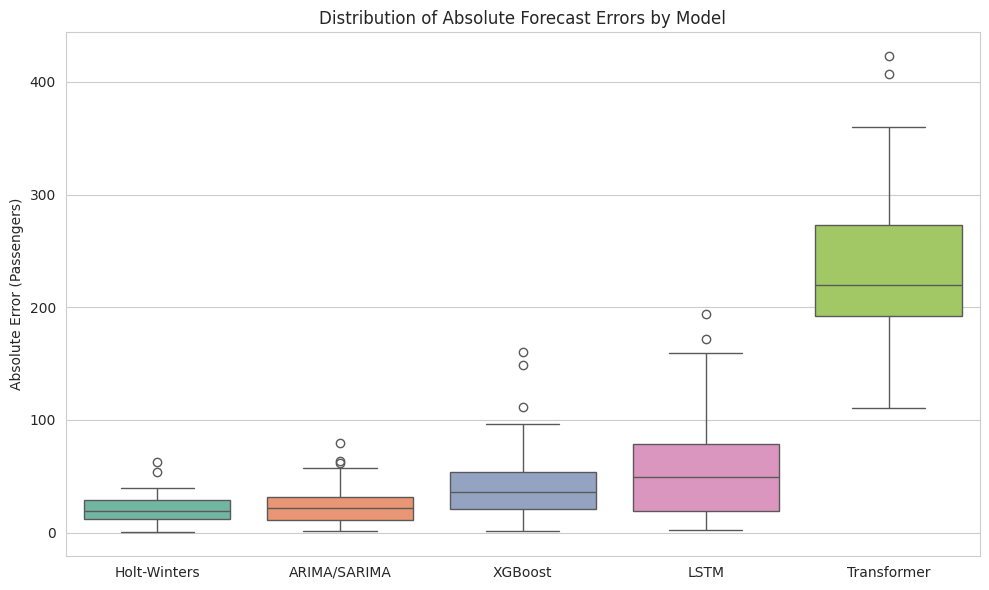

In [46]:
# 13.5 Error distribution boxplot (per-timestamp absolute errors)
err_df = pd.DataFrame(errors_by_model, index=idx_test)
plt.figure(figsize=(10,6))
sns.boxplot(data=err_df, palette="Set2")
plt.title("Distribution of Absolute Forecast Errors by Model")
plt.ylabel("Absolute Error (Passengers)")
plt.tight_layout()
plt.show()

## 14. Statistical Comparison of Results (Step 12)

Because every model was evaluated on the **same aligned test timestamps**, the per-point
absolute errors are paired observations — enabling a valid **paired t-test** (or Wilcoxon
signed-rank test when normality is violated) between every pair of models.

**H₀:** No significant difference in forecast error between the two models
**H₁:** A significant difference exists

In [47]:
from itertools import combinations
from scipy.stats import wilcoxon, shapiro

model_names = list(errors_by_model.keys())
comparison_rows = []

for m1, m2 in combinations(model_names, 2):
    e1, e2 = errors_by_model[m1], errors_by_model[m2]
    diff = e1 - e2

    # Normality check on the differences (Shapiro-Wilk)
    try:
        _, p_norm = shapiro(diff)
    except Exception:
        p_norm = np.nan
    normal = p_norm > 0.05 if not np.isnan(p_norm) else False

    t_stat, p_t = stats.ttest_rel(e1, e2)
    try:
        w_stat, p_w = wilcoxon(e1, e2)
    except Exception:
        w_stat, p_w = np.nan, np.nan

    comparison_rows.append({
        "Model A": m1, "Model B": m2,
        "Shapiro p (normality of diff)": round(p_norm, 4) if not np.isnan(p_norm) else np.nan,
        "Paired t-test p-value": round(p_t, 4),
        "Significant (t-test, a=0.05)": p_t < 0.05,
        "Wilcoxon p-value": round(p_w, 4) if not np.isnan(p_w) else np.nan,
        "Significant (Wilcoxon, a=0.05)": (p_w < 0.05) if not np.isnan(p_w) else np.nan,
        "Recommended test": "t-test" if normal else "Wilcoxon"
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model A,Model B,Shapiro p (normality of diff),Paired t-test p-value,"Significant (t-test, a=0.05)",Wilcoxon p-value,"Significant (Wilcoxon, a=0.05)",Recommended test
0,Holt-Winters,ARIMA/SARIMA,0.9881,0.0641,False,0.0592,False,t-test
1,Holt-Winters,XGBoost,0.1298,0.0004,True,0.0003,True,t-test
2,Holt-Winters,LSTM,0.0098,0.0002,True,0.0001,True,Wilcoxon
3,Holt-Winters,Transformer,0.3863,0.0000,True,0.0000,True,t-test
4,ARIMA/SARIMA,XGBoost,0.1406,0.0007,True,0.0007,True,t-test
5,ARIMA/SARIMA,LSTM,0.0060,0.0007,True,0.0035,True,Wilcoxon
6,ARIMA/SARIMA,Transformer,0.2067,0.0000,True,0.0000,True,t-test
7,XGBoost,LSTM,0.4010,0.0489,True,0.0837,False,t-test
8,XGBoost,Transformer,0.2173,0.0000,True,0.0000,True,t-test
9,LSTM,Transformer,0.0022,0.0000,True,0.0000,True,Wilcoxon


In [48]:
comparison_df.to_csv("airline_statistical_comparison.csv", index=False)
print("Saved: airline_statistical_comparison.csv")

Saved: airline_statistical_comparison.csv
